In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report
import numpy as np

# **Loading the Dataset**

In [9]:
file_path = '/Users/deekshitchowdaryvardhineni/Documents/Dredging(mini)/DredgingDataset.csv'
dataset = pd.read_csv(file_path)

# **Data Preprocessing**

In [10]:
dataset['Cost of Dredging Operations (₹)'] = dataset['Cost of Dredging Operations (₹)'].replace({',': ''}, regex=True).astype(float)
label_encoder = LabelEncoder()
dataset['Sediment Type'] = label_encoder.fit_transform(dataset['Sediment Type'])
dataset['Type of Water Body'] = label_encoder.fit_transform(dataset['Type of Water Body'])
dataset['Decision Attribute'] = label_encoder.fit_transform(dataset['Decision Attribute'])  # Yes=1, No=0

# **Defining Features and Targets for Classification and Regression**

In [11]:
X = dataset.drop(columns=['Data Field', 'Cost of Dredging Operations (₹)', 'Decision Attribute'])
y_classification = dataset['Decision Attribute']
y_regression = dataset['Cost of Dredging Operations (₹)']

# **Splitting Data into Training and Testing Sets**

In [12]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_classification, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42)

# **Model Training: Classification Model (RandomForestClassifier)**

In [13]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_class, y_train_class)
y_pred_class = clf.predict(X_test_class)

# **Model Training: Regression Model (RandomForestRegressor)**

In [14]:
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)

# **Classification Report**

In [15]:
print("Classification Report (Dredging Decision):")
print(classification_report(y_test_class, y_pred_class))

Classification Report (Dredging Decision):
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        30
           1       0.97      0.96      0.96        70

    accuracy                           0.95       100
   macro avg       0.94      0.95      0.94       100
weighted avg       0.95      0.95      0.95       100



# **Prediction Function for Dredging Decision and Cost Estimation**


In [16]:
def predict_dredging(features):
    input_df = pd.DataFrame([features], columns=X.columns)
    
    dredging_decision = clf.predict(input_df)[0]
    dredging_decision_label = 'Yes' if dredging_decision == 1 else 'No'
    
    estimated_cost = reg.predict(input_df)[0]
    
    previous_dredging_year = features[4]
    sediment_type = label_encoder.inverse_transform([features[1]])[0]
    type_of_water_body = label_encoder.inverse_transform([features[5]])[0]
    
    frequency_guidelines = {
        'River': {
            'Sand': (2, 5),
            'Clay': (5, 10),
            'Silt': (3, 7)
        },
        'Lake': {
            'Sand': (5, 10),
            'Clay': (10, 20),
            'Silt': (7, 15)
        },
        'Ocean': {
            'Sand': (10, 20),
            'Clay': (20, 30),
            'Silt': (15, 25)
        }
    }
    
    dredging_range = frequency_guidelines.get(type_of_water_body, {}).get(sediment_type, (0, 0))
    min_years, _ = dredging_range
    
    if dredging_range != (0, 0):
        future_dredging_year = previous_dredging_year + min_years
    else:
        future_dredging_year = previous_dredging_year + 5

    return dredging_decision_label, estimated_cost, future_dredging_year


# **Input Data for Prediction**

In [17]:
input_data = [4, 1, 49, 10, 2023, 0, 200]
dredging_decision, estimated_cost, future_dredging_year = predict_dredging(input_data)


# **Displaying Results**

In [18]:
print(f"Dredging Decision: {dredging_decision}")
if dredging_decision == 'Yes':
    print(f"Estimated Dredging Cost: ₹{estimated_cost:.2f}")
else:
    print(f"Future Dredging Year: {future_dredging_year}")

Dredging Decision: No
Future Dredging Year: 2028


In [20]:
import joblib

# Save the trained RandomForestClassifier model
joblib.dump(clf, 'dredging_classifier.pkl')

# Save the trained RandomForestRegressor model
joblib.dump(reg, 'dredging_regressor.pkl')

# Save the LabelEncoder
joblib.dump(label_encoder, 'label_encoder.pkl')

print("Models saved successfully!")


Models saved successfully!


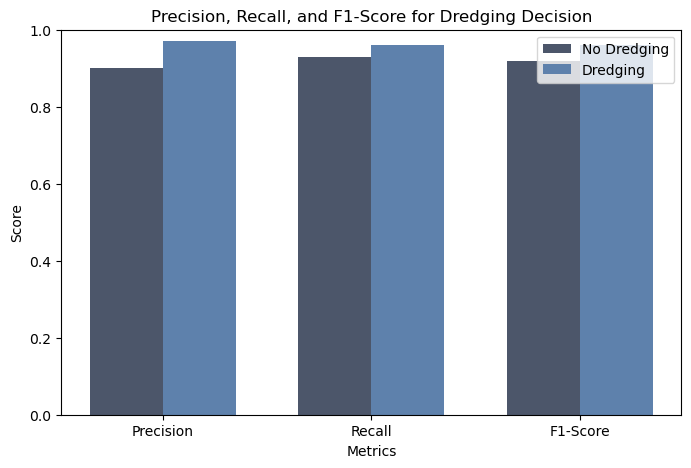

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Data for each metric and class
classes = ['No Dredging', 'Dredging']
metrics = ['Precision', 'Recall', 'F1-Score']
scores = [
    [0.90, 0.93, 0.92],  # Class 0: No Dredging
    [0.97, 0.96, 0.96]   # Class 1: Dredging
]

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
bar_width = 0.35

# Bars for each class with formal colors
ax.bar(x - bar_width / 2, scores[0], width=bar_width, label=classes[0], color='#4C566A')  # Dark gray
ax.bar(x + bar_width / 2, scores[1], width=bar_width, label=classes[1], color='#5E81AC')  # Muted blue

# Labeling
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-Score for Dredging Decision')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Display plot with y-axis range from 0 to 1
plt.ylim(0, 1)
plt.show()
